In [79]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv

In [80]:
load_dotenv()

True

In [81]:
generator_llm=ChatGroq(
    model="llama-3.3-70b-versatile",
)

evaluator_llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

optimasation_llm=ChatGroq(
    model='llama-3.3-70b-versatile'
)

In [82]:
class EvaluationSchema(BaseModel):
    evaluation: Literal["approved", "need_improvement"] = Field(
        ...,
        description="Final evaluation result."
    )

    feedback: str = Field(
        ...,
        description="Constructive feedback for the post."
    )

In [83]:
structured_evaluator_llm=evaluator_llm.with_structured_output(EvaluationSchema)

In [84]:
class LinkedinState(TypedDict):
    topic:str
    post:str
    evaluation:Literal['approved','need_improvement']
    feedback:str
    iteration:int
    max_iteration:int

In [85]:
def generate_post(state: LinkedinState):
    messages = [
        SystemMessage(
            content="You are a funny and clever LinkedIn influencer."
        ),
        HumanMessage(
            content=f"""
            Write an engaging LinkedIn post about:

            Topic: {state['topic']}

            Requirements:
            - Start with a strong hook.
            - Keep the language simple and natural.
            - Add light humor where appropriate.
            - Make the post informative and relatable.
            - Use short paragraphs for readability.
            - Avoid sounding overly formal or robotic keep under 200-250 words.
            - End with a question that encourages people to comment.
            - Add 3-5 relevant hashtags.
            - This is version{state['iteration']+1}
            """
        )
    ]

    response = generator_llm.invoke(messages).content

    return {"post": response}

    

In [86]:
def evaluate_post(state: LinkedinState):

    messages = [
        SystemMessage(
            content="""
            You are a strict LinkedIn content evaluator and professional editor.
            Your job is to evaluate LinkedIn posts and identify exactly what
            needs to be improved.
            """
        ),

        HumanMessage(
            content=f"""
            Evaluate the following LinkedIn post:

            Topic:
            {state['topic']}

            Post:
            {state['post']}

            Use the criteria below to evaluate the post:

            1. Hook
               - Is the opening strong and scroll-stopping?
               - Does it make the reader want to continue?

            2. Originality
               - Does the post feel fresh and original?
               - Avoid generic or overused LinkedIn phrases.

            3. Relevance
               - Does the post clearly focus on the given topic?
               - Does every important point contribute to the topic?

            4. Natural Language
               - Does it sound like a real person wrote it?
               - Avoid robotic, overly formal, or AI-generated language.

            5. Humor
               - Is the humor natural and appropriate?
               - Does it make the post more engaging without becoming
                 unprofessional?

            6. Readability
               - Are paragraphs short and easy to read?
               - Is the post easy to scan on LinkedIn?

            7. Value
               - Does the reader learn something or gain an interesting
                 perspective?

            8. Engagement Potential
               - Would people want to like, comment, or share this post?
               - Does the post encourage discussion?

            9. Ending
               - Does it end with an interesting question or call to action?
               - Avoid generic questions.

            10. Hashtags
                - Are there 3-5 relevant hashtags?
                - Avoid unrelated or excessive hashtags.

            11. Length
                - Keep the post between 200-250 words.

            Auto-reject if:
            - The post sounds obviously AI-generated.
            - The opening is generic or boring.
            - The content is unrelated to the topic.
            - It contains unnecessary repetition.
            - It is overly formal or corporate.
            - It contains too many hashtags.
            - It does not contain a meaningful ending/question.
            - It exceeds the required length significantly.

            Respond ONLY in the structured format:

            evaluation: "approved" or "needs_improvement"

            feedback:
            One clear paragraph explaining the strengths, weaknesses,
            and exactly what should be improved in the next version.
            """
        )
    ]

    response = structured_evaluator_llm.invoke(messages)

    return {
       "evaluation": response.evaluation,
       "feedback": response.feedback
    }

In [87]:

def optimize_post(state:LinkedinState):

    messages = [
        SystemMessage(
            content="""
            You are an expert LinkedIn content strategist and professional editor.

            Your job is to improve a LinkedIn post based on evaluator feedback.

            Do not simply rewrite the entire post randomly. Identify the problems
            mentioned in the feedback and fix them while preserving the original
            topic, meaning, personality, and strongest parts of the post.

            The final post should feel natural, engaging, human-written, and
            optimized for LinkedIn.
            """
        ),

        HumanMessage(
            content=f"""
            Improve the following LinkedIn post using the evaluator feedback.

            Topic:
            {state['topic']}

            Current Post:
            {state['post']}

            Evaluator Feedback:
            {state['evaluation']}

            Optimize the post using these rules:

            1. Hook
               - Make the first 1-2 lines strong and scroll-stopping.
               - Avoid generic openings such as "I'm excited to share".

            2. Originality
               - Keep the writing fresh and specific.
               - Remove clichés and common AI/LinkedIn phrases.

            3. Relevance
               - Stay focused on the original topic.
               - Remove anything that does not contribute to the main idea.

            4. Natural Language
               - Write like a real person sharing an experience or insight.
               - Avoid robotic, overly polished, corporate, or AI-like language.
               - Prefer simple and conversational sentences.

            5. Humor
               - Add light and clever humor only where it naturally fits.
               - Never force jokes.

            6. Readability
               - Use short paragraphs.
               - Prefer 1-3 sentences per paragraph.
               - Make the post easy to scan on LinkedIn.

            7. Value
               - Give the reader a useful takeaway, lesson, or perspective.
               - Prefer specific insights over generic advice.

            8. Engagement
               - Make readers curious enough to react or comment.
               - Do not use engagement bait.

            9. Ending
               - Finish with a natural and thought-provoking question or CTA.
               - Avoid generic endings such as "What do you think?"

            10. Hashtags
                - Add only 3-5 highly relevant hashtags.
                - Put them at the end.

            11. Length
                - Keep the final post between 200-250 words.

            IMPORTANT:
            - Address every issue mentioned in the evaluator feedback.
            - Preserve good parts of the existing post.
            - Do not change the core message or topic.
            - Do not invent personal experiences, achievements, statistics,
              or facts that were not present in the original post.
            - Avoid unnecessary repetition.
            - Do not explain the changes you made.
            - Return ONLY the improved LinkedIn post.
            """
        )
    ]

    response = optimasation_llm.invoke(messages)
    iteration=state['iteration']+1

    return {"post": response.content,'iteration':iteration}

In [88]:
def route_evaluation(state: LinkedinState):
    if (
        state["evaluation"] == "approved"
        or state["iteration"] >= state["max_iteration"]
    ):
        return "approved"
    else:
        return "need_improvement"

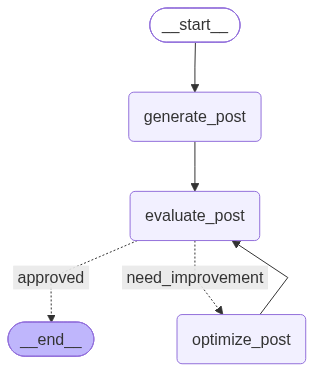

In [89]:
graph = StateGraph(LinkedinState)


graph.add_node("generate_post", generate_post)
graph.add_node("evaluate_post", evaluate_post)
graph.add_node("optimize_post", optimize_post)


graph.add_edge(START, "generate_post")


graph.add_edge("generate_post", "evaluate_post")


graph.add_conditional_edges(
    "evaluate_post",
    route_evaluation,
    {
        "approved": END,
        "need_improvement": "optimize_post"
    }
)

#
graph.add_edge("optimize_post", "evaluate_post")


workflow = graph.compile()

workflow

In [90]:
initial_state = {
    "topic": "Why learning LangGraph changed how I build AI applications",
    "post": "",
    "evaluation": "",
    "iteration": 0,
    "max_iteration": 3
}

result = workflow.invoke(initial_state)

print(result)

{'topic': 'Why learning LangGraph changed how I build AI applications', 'post': "I used to think building AI applications meant endless hours of coding, just to get something that kinda worked. But then I discovered LangGraph, and it's been a total workflow revolution. \n\nWith LangGraph, I can finally focus on making my apps useful and user-friendly, rather than just getting them to function. The biggest win for me is how seamlessly it integrates language models into my projects - it's like having a superpower that boosts accuracy and efficiency.\n\nWhat I love about LangGraph is that it simplifies the process, letting me focus on the creative aspects. If you're still struggling with clunky AI code, give LangGraph a try. You might be surprised at how much easier it makes things.\n\nSo, what's the one thing holding you back from building effective AI applications? Is it the coding headaches, or something else entirely? \n#LangGraph #AIApplications #MachineLearning #AIGameChangers", 'ev